# Constant Velocity Scenario Comparison

This notebook combines the classical EKF experiment and the trained Distributed KalmanNet workflow in one place. It compares `CEKF`, `DEKF`, and `DKN` on the same constant-velocity distance/angle tracking scenario.

In [1]:
import importlib
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "utils").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

torch.set_default_dtype(torch.float32)

import utils.ConstantVelocityScenario as constant_velocity_scenario_module
importlib.reload(constant_velocity_scenario_module)

from utils.ClassicDistributedKalman import (
    centralized_extended_kalman_filter,
    diffusion_extended_kalman_filter_parallel_edge,
)
from utils.ConstantVelocityScenario import (
    ConstantVelocityModel,
    DistanceAngleObservation,
    build_graph_data_for_dkn,
    create_distance_based_graph,
    generate_measurements,
    generate_trajectory,
    load_config,
    plot_graph,
    plot_tracking_results,
    plot_trajectory_and_nodes,
    seed_everything,
)
from utils.DistributedKalmanNet import GraphKalmanProcess

/home/kfir-goldring/PycharmProjects/distributedKNET/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Scenario Setup

Use one fixed sensor layout and one constant-velocity model so that all three methods are evaluated on the same simulated data.

Loaded config from: /home/kfir-goldring/PycharmProjects/distributedKNET/configs/const_vel_scenario_configured.json
config_val:
batch_size                                                                 64
graph_seed                                                                 42
hidden_dim                                                                128
k_neighbors                                                                 5
learn_edge_kalman                                                       False
learning_rate                                                         0.00001
log_root                            models/kfir/const_vel_scenario_configured
max_epochs                                                                100
measurement_noise_values                               [0.25, 0.5, 0.75, 1.0]
node_positions              [[37.45401188, 95.07143064], [73.19939418, 59....
num_nodes                                                                  10
num_trials     

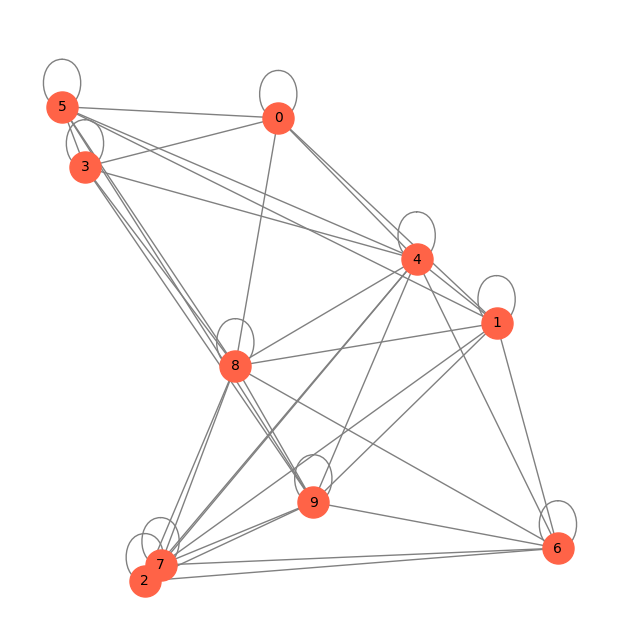

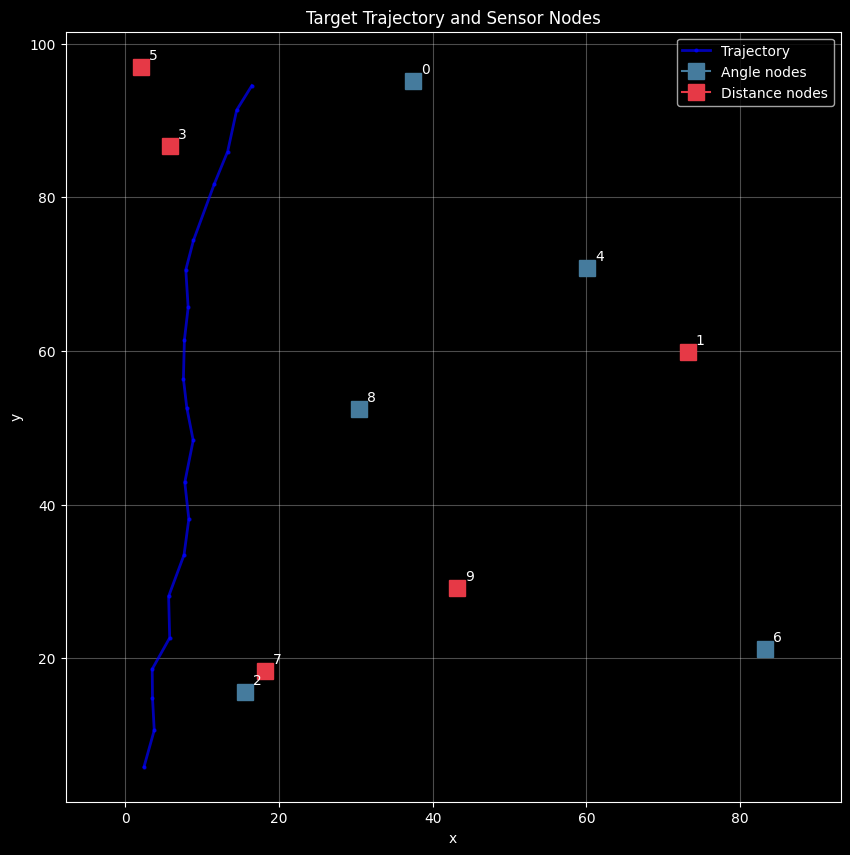

In [2]:
config_path = REPO_ROOT / "configs" / "const_vel_scenario_configured.json"
config_val = load_config(config_path)
seed_everything(config_val["seed"])

num_nodes = config_val["num_nodes"]
state_dimension = config_val["state_dimension"]
train_time_steps = config_val.get("train_time_steps", config_val["time_steps"])
test_time_steps = config_val.get("test_time_steps", config_val.get("train_time_steps", config_val["time_steps"]))
num_time_steps = test_time_steps
num_trials = config_val["num_trials"]
process_noise_std = config_val["process_noise_std"]
time_delta = config_val["time_delta"]
measurement_noise_values = config_val["measurement_noise_values"]

x_init = np.array(config_val["x0"], dtype=float).reshape(state_dimension, 1)
p0 = np.eye(state_dimension) * config_val["p0_scale"]

node_positions = np.array(config_val["node_positions"], dtype=float)
f_system = ConstantVelocityModel(time_delta)
h_system = DistanceAngleObservation(node_positions)
adjacency_matrix = create_distance_based_graph(
    node_positions,
    k_neighbors=config_val["k_neighbors"],
    seed=config_val["graph_seed"],
)
j_matrix = np.array(adjacency_matrix, dtype=float, copy=True)
np.fill_diagonal(j_matrix, 1.0)
node_types = h_system.node_classification[:, 0].numpy().astype(int)
save_root = REPO_ROOT / config_val["save_root"]

def get_trial_data(r_noise):
    trajectory = generate_trajectory(f_system, x_init, num_time_steps, process_noise_std)
    measurements = generate_measurements(h_system, trajectory, r_noise)
    return trajectory, measurements

example_r = measurement_noise_values[0]
example_run_name = f"const_vel_scenario_r={example_r}"
example_config_path = save_root / "configs" / f"{example_run_name}.json"
example_model_path = save_root / "DKN" / f"{example_run_name}.pth"

print(f"Loaded config from: {config_path}")
print("config_val:")
print(pd.Series(config_val))
print("\nNode positions:")
print(node_positions)
print(f"Train time steps: {train_time_steps}")
print(f"Test time steps:  {test_time_steps}")
print(f"Example config path: {example_config_path}")
print(f"Example model path:  {example_model_path}")
plot_graph(adjacency_matrix, node_positions, title="Constant Velocity Scenario Graph")
plot_trajectory_and_nodes(node_positions, node_types, generate_trajectory(f_system, x_init, num_time_steps, process_noise_std))


## Single-Trial Comparison

Run one scenario and visualize the trajectory estimates from `CEKF`, `DEKF`, and `DKN` on exactly the same measurements.

/home/kfir-goldring/PycharmProjects/distributedKNET/utils/ConstantVelocityScenario.py:448: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  trajectory_tensor = torch.tensor(trajectory, dtype=torch.float32)


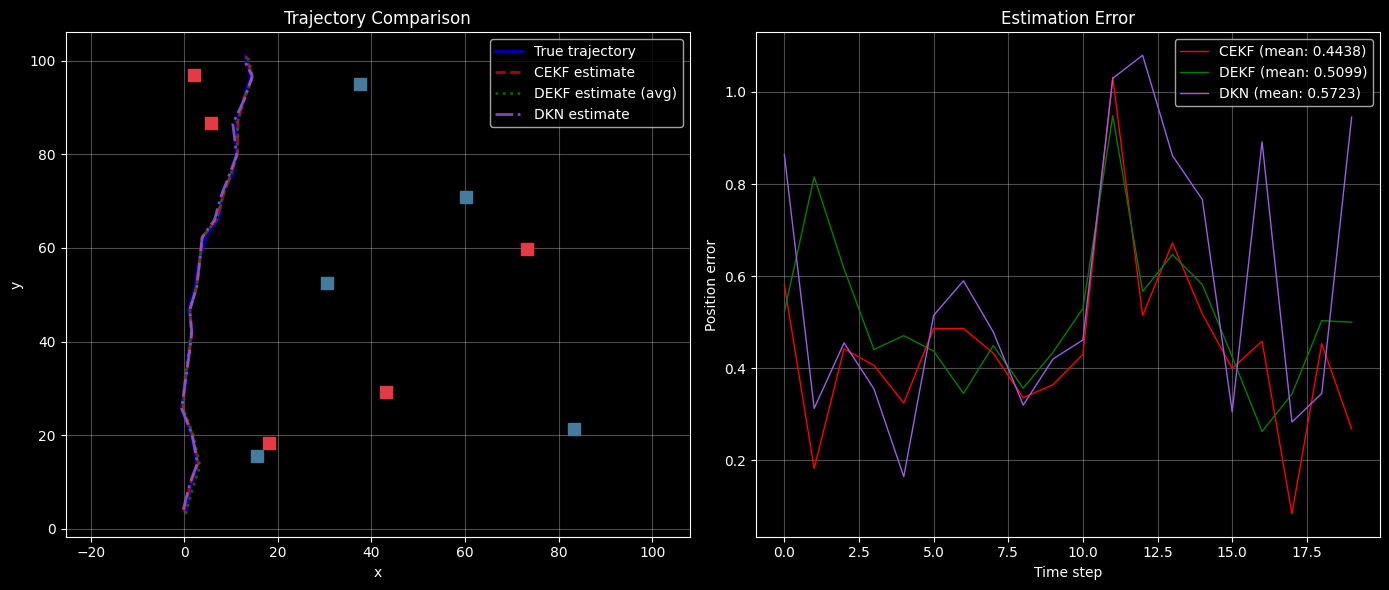

In [3]:
r_demo = 0.5
trajectory, measurements = get_trial_data(r_demo)

x_hat_cekf = centralized_extended_kalman_filter(
    measurements=measurements,
    f_system=f_system,
    h_system=h_system,
    r_array=r_demo * np.ones(num_nodes),
    q=process_noise_std,
    p0=p0,
    x0=x_init,
    time_steps=num_time_steps,
    node_num=num_nodes,
)

x_hat_dekf = diffusion_extended_kalman_filter_parallel_edge(
    measurements=measurements,
    f_system=f_system,
    h_system=h_system,
    r_array=r_demo * np.ones(num_nodes),
    q=process_noise_std,
    p0=p0,
    x0=x_init,
    j_matrix=j_matrix,
    time_steps=num_time_steps,
    node_num=num_nodes,
)

graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)
kalman_process = GraphKalmanProcess(
    f_system,
    signal_dim=state_dimension,
    edge_features_dim=1,
    node_kalman_dim=state_dimension**2,
    edge_kalman_dim=2,
    hidden_dim=config_val["hidden_dim"],
    lr=config_val["learning_rate"],
    r_array=r_demo,
    learn_edge_kalman=config_val["learn_edge_kalman"],
    x0_scale=x_init,
)
run_name_demo = f"const_vel_scenario_r={r_demo}"
example_config_path = save_root / "configs" / f"{run_name_demo}.json"
example_model_path = save_root / "DKN" / f"{run_name_demo}.pth"
kalman_process.load_state_dict(torch.load(example_model_path, map_location="cpu"))
kalman_process.eval()
with torch.no_grad():
    x_hat_dkn = kalman_process(graph_data).squeeze().cpu().numpy().mean(axis=1)

plot_tracking_results(
    trajectory,
    x_hat_cekf,
    x_hat_dekf=x_hat_dekf,
    x_hat_dkn=x_hat_dkn,
    node_positions=node_positions,
    node_types=node_types,
)

## Monte Carlo Study

For each measurement noise level, evaluate `CEKF`, `DEKF`, and the matching trained `DKN` model on the same set of randomly generated trajectories and compare average position error.

In [4]:
avg_error_cekf = []
avg_error_dekf = []
avg_error_dkn = []

for r_noise in measurement_noise_values:
    r_array = r_noise * np.ones(num_nodes)
    run_name = f"const_vel_scenario_r={r_noise}"
    example_config_path = save_root / "configs" / f"{run_name}.json"
    example_model_path = save_root / "DKN" / f"{run_name}.pth"

    kalman_process = GraphKalmanProcess(
        f_system,
        signal_dim=state_dimension,
        edge_features_dim=1,
        node_kalman_dim=state_dimension**2,
        edge_kalman_dim=2,
        hidden_dim=config_val["hidden_dim"],
        lr=config_val["learning_rate"],
        r_array=r_noise,
        learn_edge_kalman=config_val["learn_edge_kalman"],
        x0_scale=x_init,
    )
    kalman_process.load_state_dict(torch.load(example_model_path, map_location="cpu"))
    kalman_process.eval()

    trial_errors_cekf = []
    trial_errors_dekf = []
    trial_errors_dkn = []

    for _ in tqdm(range(num_trials), desc=f"r={r_noise}"):
        trajectory, measurements = get_trial_data(r_noise)

        x_hat_cekf = centralized_extended_kalman_filter(
            measurements=measurements,
            f_system=f_system,
            h_system=h_system,
            r_array=r_array,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            time_steps=num_time_steps,
            node_num=num_nodes,
        )
        x_hat_dekf = diffusion_extended_kalman_filter_parallel_edge(
            measurements=measurements,
            f_system=f_system,
            h_system=h_system,
            r_array=r_array,
            q=process_noise_std,
            p0=p0,
            x0=x_init,
            j_matrix=j_matrix,
            time_steps=num_time_steps,
            node_num=num_nodes,
        )

        graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)
        with torch.no_grad():
            x_hat_dkn = kalman_process(graph_data).squeeze().cpu().numpy().mean(axis=1)

        x_true = trajectory[:, 0, 0].numpy()
        y_true = trajectory[:, 2, 0].numpy()

        x_cekf = x_hat_cekf[:, 0, 0]
        y_cekf = x_hat_cekf[:, 2, 0]
        trial_errors_cekf.append(np.sqrt((x_true - x_cekf) ** 2 + (y_true - y_cekf) ** 2).mean())

        x_dekf = x_hat_dekf[:, :, 0, 0].mean(axis=1)
        y_dekf = x_hat_dekf[:, :, 2, 0].mean(axis=1)
        trial_errors_dekf.append(np.sqrt((x_true - x_dekf) ** 2 + (y_true - y_dekf) ** 2).mean())

        trial_errors_dkn.append(np.sqrt((x_true - x_hat_dkn[:, 0]) ** 2 + (y_true - x_hat_dkn[:, 2]) ** 2).mean())

    avg_error_cekf.append(np.mean(trial_errors_cekf))
    avg_error_dekf.append(np.mean(trial_errors_dekf))
    avg_error_dkn.append(np.mean(trial_errors_dkn))

results_df = pd.DataFrame(
    {
        "measurement_noise": measurement_noise_values,
        "CEKF": avg_error_cekf,
        "DEKF": avg_error_dekf,
        "DKN": avg_error_dkn,
    }
)
results_df

r=1.0: 100%|██████████| 50/50 [00:02<00:00, 21.53it/s]


,measurement_noise,CEKF,DEKF,DKN
0,0.25,0.234162,0.321008,0.347761
1,0.50,0.434073,0.566809,0.510980
2,0.75,0.641124,0.762609,0.675525
3,1.00,0.819253,0.949614,0.799399


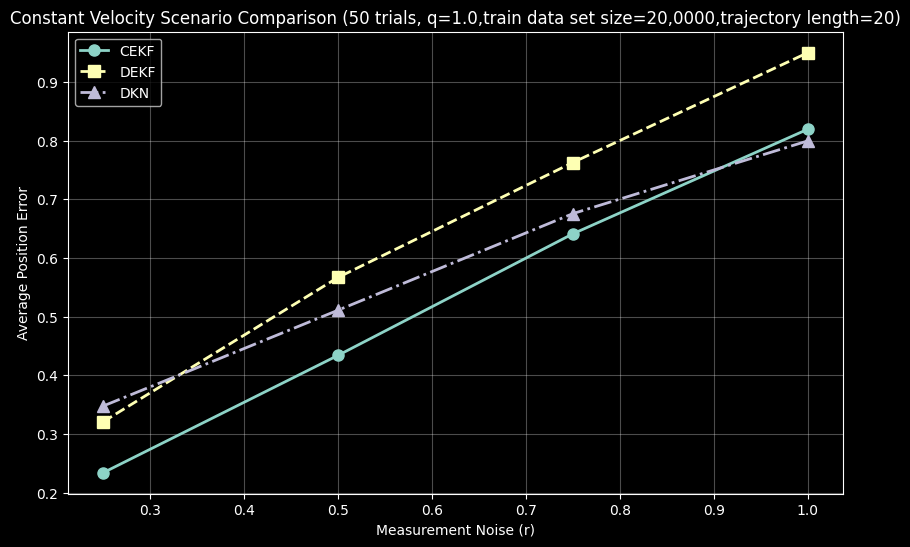

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(results_df["measurement_noise"], results_df["CEKF"], "o-", linewidth=2, markersize=8, label="CEKF")
plt.plot(results_df["measurement_noise"], results_df["DEKF"], "s--", linewidth=2, markersize=8, label="DEKF")
plt.plot(results_df["measurement_noise"], results_df["DKN"], "^-.", linewidth=2, markersize=8, label="DKN")
plt.xlabel("Measurement Noise (r)")
plt.ylabel("Average Position Error")
plt.title(f"Constant Velocity Scenario Comparison ({num_trials} trials, q={process_noise_std},train data set size=20,0000,trajectory length={num_time_steps})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()